In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import statsmodels.api as sm
import getFamaFrenchFactors as gff

In [42]:
rets = yf.download(['VTI','VLUE','MTUM'], interval = '1mo', auto_adjust = True, start = '2000-01-01')['Close']
rets = rets.to_period('M').pct_change().dropna()

[*********************100%***********************]  2 of 3 completed


In [43]:
rets.tail()

Ticker,MTUM,VLUE,VTI
Date,,,
2026-03,-0.050423,-0.052945,-0.050048
2026-04,0.183299,0.174977,0.104018
2026-05,0.112085,0.185850,0.051838
2026-06,0.086757,0.012086,-0.003853
2026-07,-0.128402,-0.034057,-0.010648


In [44]:
ff_5f = gff.famaFrench5Factor().set_index('date_ff_factors').to_period('M')
ff_momentum = gff.momentumFactor().set_index('date_ff_factors').to_period('M')

<Axes: xlabel='date_ff_factors'>

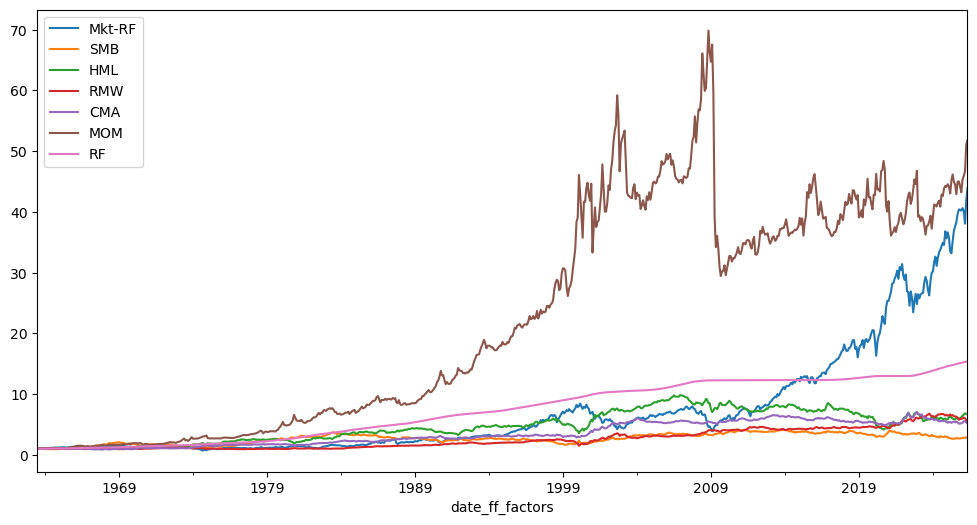

In [45]:
ff_6f = ff_5f.join(ff_momentum)
ff_6f = ff_6f[[*ff_6f.columns.drop('RF'),'RF']]
(1+ff_6f).cumprod().plot(figsize=(12,6))

In [46]:
def factor_regression(rets, factor_model):
    # common index
    common_idx = rets.index.intersection(factor_model.index)
    rets = rets.loc[common_idx]
    factor_model = factor_model.loc[common_idx]

    # prep data for regression
    rets_excess = rets - factor_model[['RF']].values
    factor_model_minus_RFR = factor_model[[*ff_6f.columns.drop('RF')]]
    factor_model_minus_RFR['Alpha'] = 1

    # run regression
    lm = sm.OLS(rets_excess, factor_model_minus_RFR).fit()
    factor_loadings = lm.params
    factor_loadings.columns = rets.columns

    # calculate annualized alpha
    alpha_per_period = factor_loadings.loc[['Alpha']]
    annualized_alpha = ((1+alpha_per_period)**12)-1
    annualized_alpha.index = ['Annualized Alpha']
    factor_loadings = pd.concat([factor_loadings, annualized_alpha])

    # alpha & annualized alpha in %
    factor_loadings = factor_loadings.round(2)
    factor_loadings = factor_loadings.astype(object)
    factor_loadings.loc[['Alpha']] = (alpha_per_period * 100).round(2).astype(str) + '%'
    factor_loadings.loc[['Annualized Alpha']] = (annualized_alpha * 100).round(2).astype(str) + '%'

    return factor_loadings

In [47]:
factor_regression(rets, ff_6f)

Ticker,MTUM,VLUE,VTI
Mkt-RF,1.09,1.04,0.99
SMB,-0.13,-0.03,0.0
HML,-0.04,0.43,0.01
RMW,-0.15,-0.25,0.02
CMA,0.06,0.07,0.0
MOM,0.4,-0.03,0.01
Alpha,-0.07%,0.01%,-0.02%
Annualized Alpha,-0.83%,0.18%,-0.28%


In [48]:
def rolling_factor_regression(rets, factor_model, roll_window=36):
    # common index
    common_idx = rets.index.intersection(factor_model.index)
    rets = rets.loc[common_idx]
    factor_model = factor_model.loc[common_idx]

    # prep data for regression
    rets_excess = rets - factor_model[['RF']].values
    factor_model_minus_RF = factor_model[[*ff_6f.columns.drop('RF')]]

    # rolling
    n_periods = rets.shape[0]
    windows = [(start, start + roll_window) for start in range(n_periods - roll_window + 1)]

    if n_periods <= roll_window:
        print('Sample smaller than roll window.')
        return
    
    # rolling regression
    results = {}
    for ret_excess in rets_excess:
        factor_loadings_per_window = []
        for win in windows:
            lm = sm.OLS(rets_excess[ret_excess].iloc[win[0]:win[1]], factor_model_minus_RF.iloc[win[0]:win[1]]).fit()
            factor_loadings = lm.params
            factor_loadings['date'] = rets_excess.index[win[1] - 1]
            factor_loadings_per_window.append(factor_loadings)
        results[ret_excess] = pd.DataFrame(factor_loadings_per_window).set_index('date')

    return results

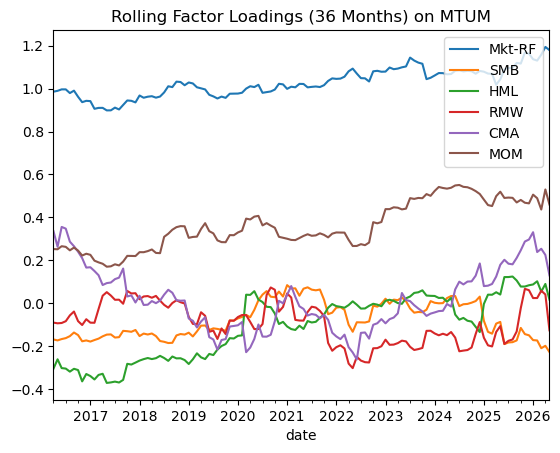

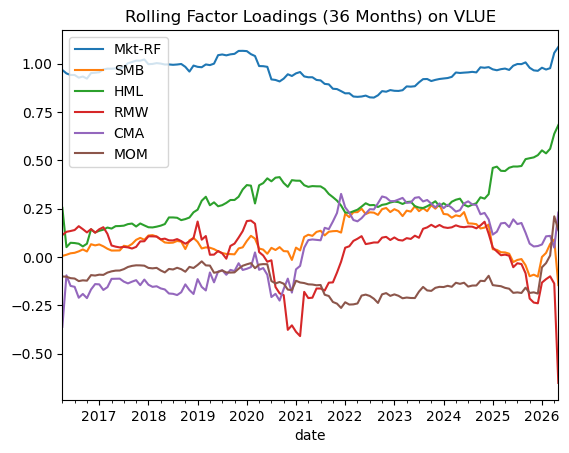

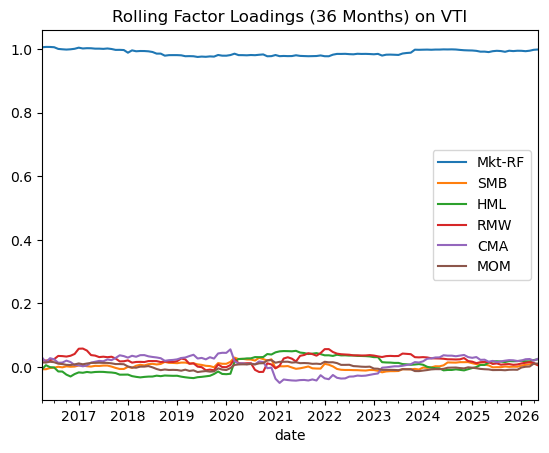

In [49]:
roll_window = 36

results = rolling_factor_regression(rets, ff_6f, roll_window)

for ticker in results:
    results[ticker].plot(title=f'Rolling Factor Loadings ({roll_window} Months) on {ticker}')